In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
df1= pd.read_csv(r"Data\DatasetWithLocations.csv")
df2 =pd.read_csv(r"Data\documentidentifier_id.csv")

df_join = pd.merge(df1, df2, left_on='GKGRECORDID', right_on='GKGRECORDID', how='inner')

df = df_join
df['Date'] = pd.to_datetime(df['DATE'], format='%Y%m%d%H%M%S')


df['Year-Month'] = df['Date'].dt.strftime('%Y-%m')


df[['tone','positive_score','negative_score','polarity', 'activity_density','self_group_density','word_count']] = df_join['V2Tone'].str.split(',', expand=True).astype(float)

df_china = df[
    df['Locations'].str.contains('china', case=False, na=False) |
    df['DocumentIdentifier'].str.contains('china', case=False, na=False)
]

df = df_china

df.columns



Index(['GKGRECORDID', 'DATE', 'SourceCommonName', 'V2Persons', 'Locations',
       'V2Tone', 'DocumentIdentifier', 'Date', 'Year-Month', 'tone',
       'positive_score', 'negative_score', 'polarity', 'activity_density',
       'self_group_density', 'word_count'],
      dtype='str')

In [4]:

df = df.sort_values('Date')

# Definition wichtiger Events
events = {
    'EU-China Gipfel (Peking)': '2023-12-07',
    'Münchner Sicherheitskonferenz': '2024-02-16',
    'Scholz China-Besuch 2024': '2024-04-14',
    'Habeck China-Besuch (Zölle)': '2024-06-21',
    'EU-Zölle auf E-Autos': '2024-07-04'}
# Hilfsfunktion für Phasen-Zuweisung (7 Tage Fenster)
def get_phase(date, event_date_str):
    evt = pd.to_datetime(event_date_str)
    diff = (date - evt).days
    if -14 <= diff < -2: return '1_Vorher'
    if -2 <= diff <= 2: return '2_Während'
    if 2 < diff <= 14: return '3_Nachher'
    return None

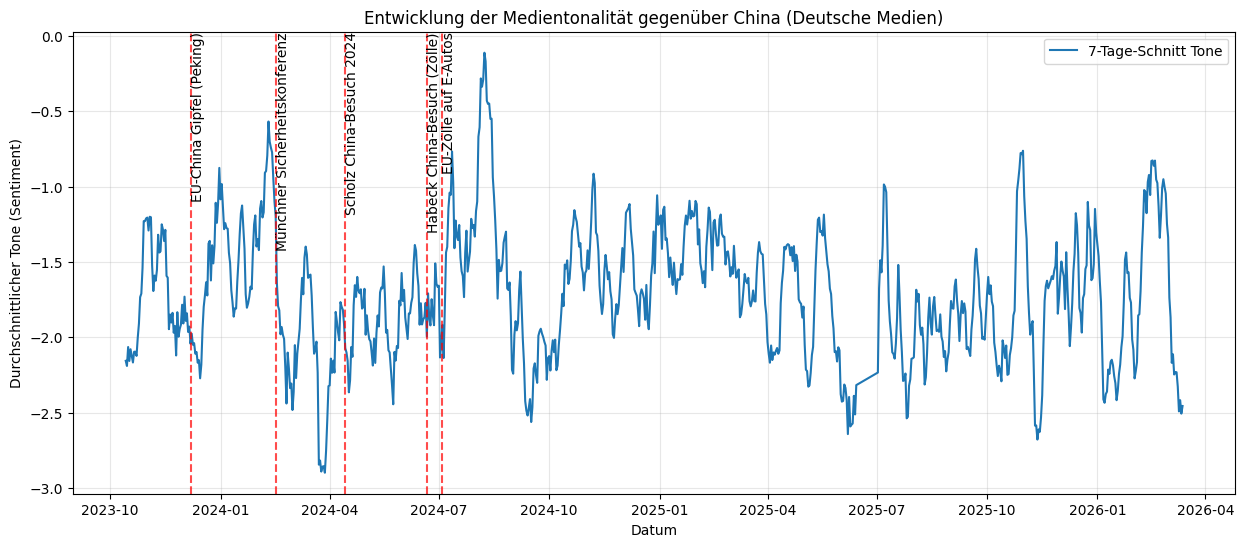

In [5]:
plt.figure(figsize=(15, 6))
# Gleitender Durchschnitt für besseren Trend
df_daily = df.groupby(df['Date'].dt.date)['tone'].mean().rolling(window=7).mean()

sns.lineplot(x=df_daily.index, y=df_daily.values, label='7-Tage-Schnitt Tone')

for name, date in events.items():
    plt.axvline(pd.to_datetime(date), color='red', linestyle='--', alpha=0.7)
    plt.text(pd.to_datetime(date), plt.ylim()[1], name, rotation=90, verticalalignment='top')

plt.title('Entwicklung der Medientonalität gegenüber China (Deutsche Medien)')
plt.ylabel('Durchschnittlicher Tone (Sentiment)')
plt.xlabel('Datum')
plt.grid(True, alpha=0.3)
plt.show()

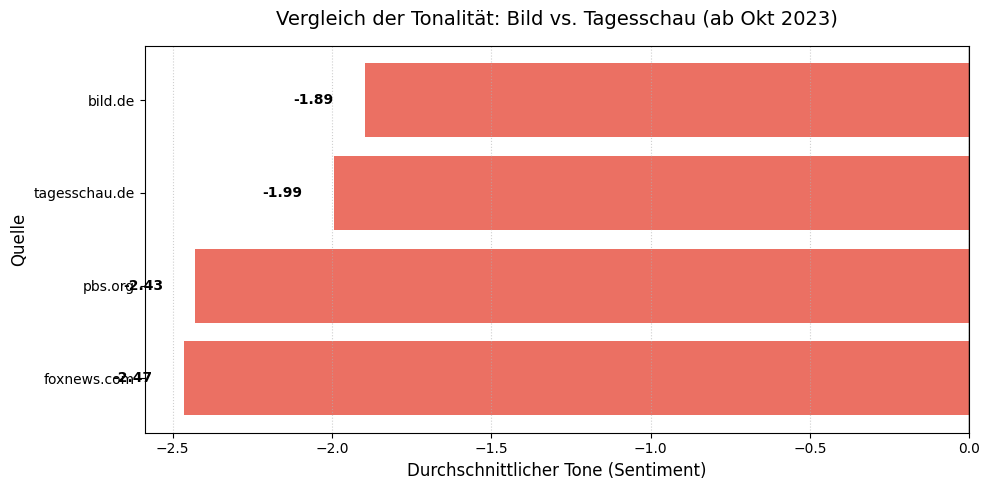

In [12]:
target_sources = ['tagesschau.de', 'bild.de', 'foxnews.com','pbs.org']

# 1. Filtern: Nur Zeilen, die 'bild' oder 'tagesschau' im Namen haben (Groß-/Kleinschreibung egal)
df_filtered = df[df['SourceCommonName'].str.lower().isin(target_sources)].copy()

# 2. Gruppieren nach der genauen Bezeichnung und Durchschnitt des 'tone' berechnen
# Wir sortieren die Ergebnisse für eine schönere Darstellung
source_analysis = df_filtered.groupby('SourceCommonName')['tone'].mean().sort_values()

# 3. Visualisierung erstellen
plt.figure(figsize=(10, 5))

# Farben: Rot für negative Werte, Grün für positive
colors = ['#e74c3c' if x < 0 else '#27ae60' for x in source_analysis.values]

# Balkendiagramm (horizontal)
bars = plt.barh(source_analysis.index, source_analysis.values, color=colors, alpha=0.8)

# Details zur Verschönerung
plt.axvline(0, color='black', linewidth=1) # Nulllinie
plt.title('Vergleich der Tonalität: Bild vs. Tagesschau (ab Okt 2023)', fontsize=14, pad=15)
plt.xlabel('Durchschnittlicher Tone (Sentiment)', fontsize=12)
plt.ylabel('Quelle', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)

# Werte direkt an die Balken schreiben
for bar in bars:
    width = bar.get_width()
    plt.text(width + (0.1 if width > 0 else -0.1), 
             bar.get_y() + bar.get_height()/2, 
             f'{width:.2f}', 
             va='center', 
             ha='left' if width > 0 else 'right', 
             fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\milad\AppData\Local\Temp\ipykernel_8312\2262367853.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


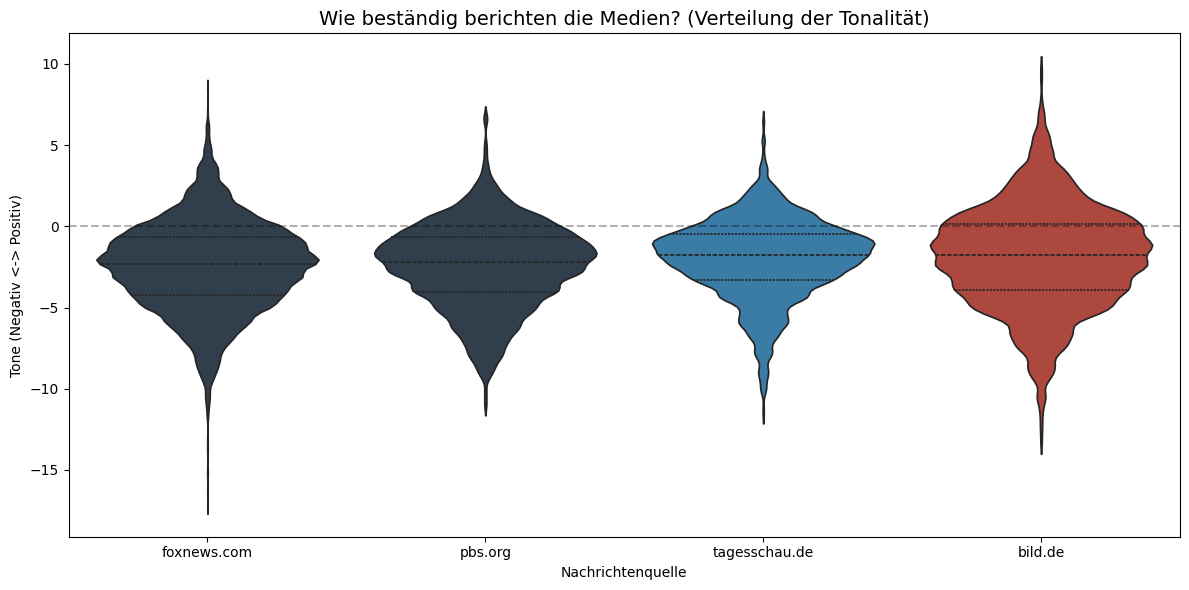

In [ ]:

# 1. Filter setzen (exakt wie zuvor)
target_sources = ['tagesschau.de', 'bild.de', 'foxnews.com','pbs.org']
df_compare = df[df['SourceCommonName'].str.lower().isin(target_sources)].copy()

# 2. Visualisierung
plt.figure(figsize=(12, 6))

# Palette definieren
palette = {'tagesschau.de': '#2980b9', 'bild.de': '#c0392b', 'foxnews.com': '#2c3e50','pbs.org': '#2c3e50'}

# Violin Plot erstellen
sns.violinplot(
    data=df_compare, 
    x='SourceCommonName', 
    y='tone', 
    palette=palette,
    inner="quartile", # Zeigt Median und Quartile innerhalb der Violine
    bw_adjust=.5      # Macht die Kurven etwas detaillierter
)

# Nulllinie für Neutralität
plt.axhline(0, color='black', linestyle='--', alpha=0.3)

plt.title('Wie beständig berichten die Medien? (Verteilung der Tonalität)', fontsize=14)
plt.ylabel('Tone (Negativ <-> Positiv)')
plt.xlabel('Nachrichtenquelle')

plt.tight_layout()
plt.show()

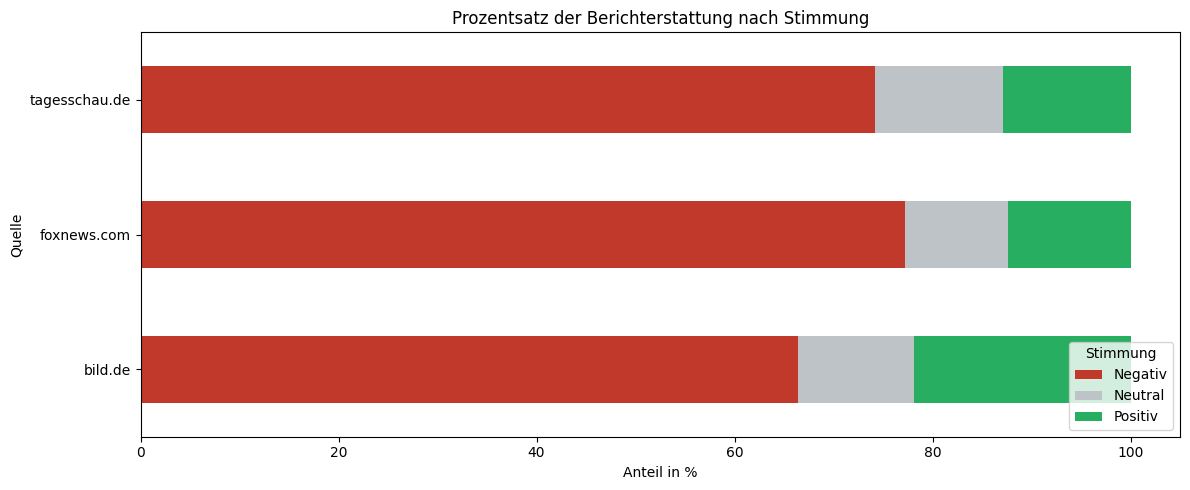

In [ ]:
def categorize_tone(t):
    if t < -0.5: return 'Negativ'
    if t > 0.5: return 'Positiv'
    return 'Neutral'

df_compare['Sentiment_Kategorie'] = df_compare['tone'].apply(categorize_tone)

# 2. Prozentuale Anteile berechnen
sentiment_counts = df_compare.groupby(['SourceCommonName', 'Sentiment_Kategorie']).size().unstack(fill_value=0)
sentiment_perc = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0) * 100

# 3. Plotten
sentiment_perc.plot(kind='barh', stacked=True, figsize=(12, 5), 
                    color={'Negativ': '#c0392b', 'Neutral': '#bdc3c7', 'Positiv': '#27ae60'})

plt.title('Prozentsatz der Berichterstattung nach Stimmung')
plt.xlabel('Anteil in %')
plt.ylabel('Quelle')
plt.legend(title='Stimmung', loc='lower right')
plt.tight_layout()
plt.show()

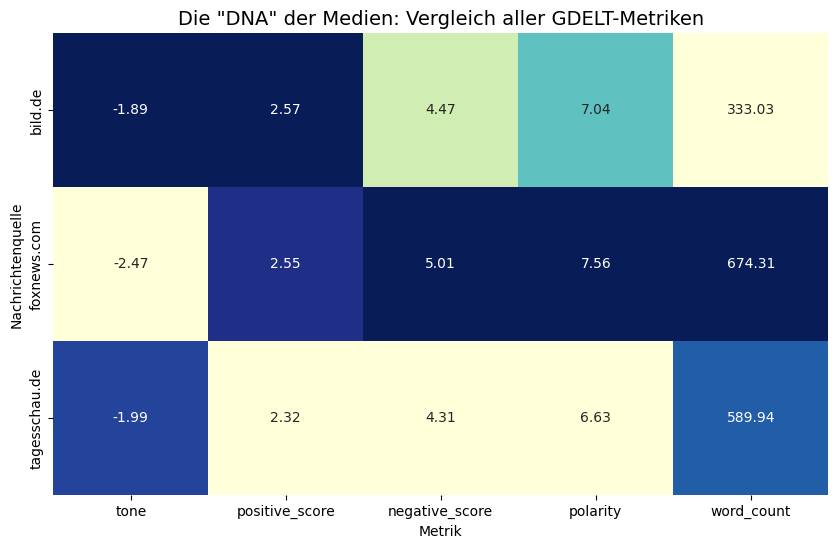

In [ ]:
# 1. Metriken auswählen und normalisieren (da word_count viel höher ist als tone)
metrics = ['tone', 'positive_score', 'negative_score', 'polarity', 'word_count']
df_profile = df_compare.groupby('SourceCommonName')[metrics].mean()

# Normalisierung (0 bis 1), damit man sie in einer Heatmap vergleichen kann
df_norm = (df_profile - df_profile.min()) / (df_profile.max() - df_profile.min())

# 2. Heatmap plotten
plt.figure(figsize=(10, 6))
sns.heatmap(df_norm, annot=df_profile, fmt=".2f", cmap="YlGnBu", cbar=False)

plt.title('Die "DNA" der Medien: Vergleich aller GDELT-Metriken', fontsize=14)
plt.xlabel('Metrik')
plt.ylabel('Nachrichtenquelle')
plt.show()

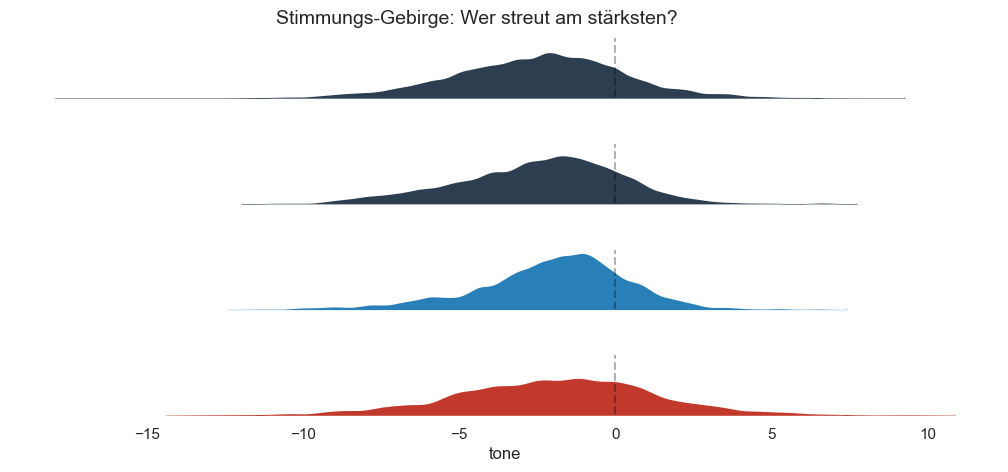

In [ ]:

sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

g = sns.FacetGrid(df_compare, row="SourceCommonName", hue="SourceCommonName", aspect=9, height=1.2, palette=palette)

# Die Dichten zeichnen
g.map(sns.kdeplot, "tone", bw_adjust=.5, clip_on=False, fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "tone", clip_on=False, color="w", lw=2, bw_adjust=.5)

# Eine Referenzlinie bei 0
g.map(plt.axvline, x=0, color="black", linestyle="--", alpha=0.3)

# Titel und Finetuning
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
plt.suptitle('Stimmungs-Gebirge: Wer streut am stärksten?', fontsize=14)
plt.show()

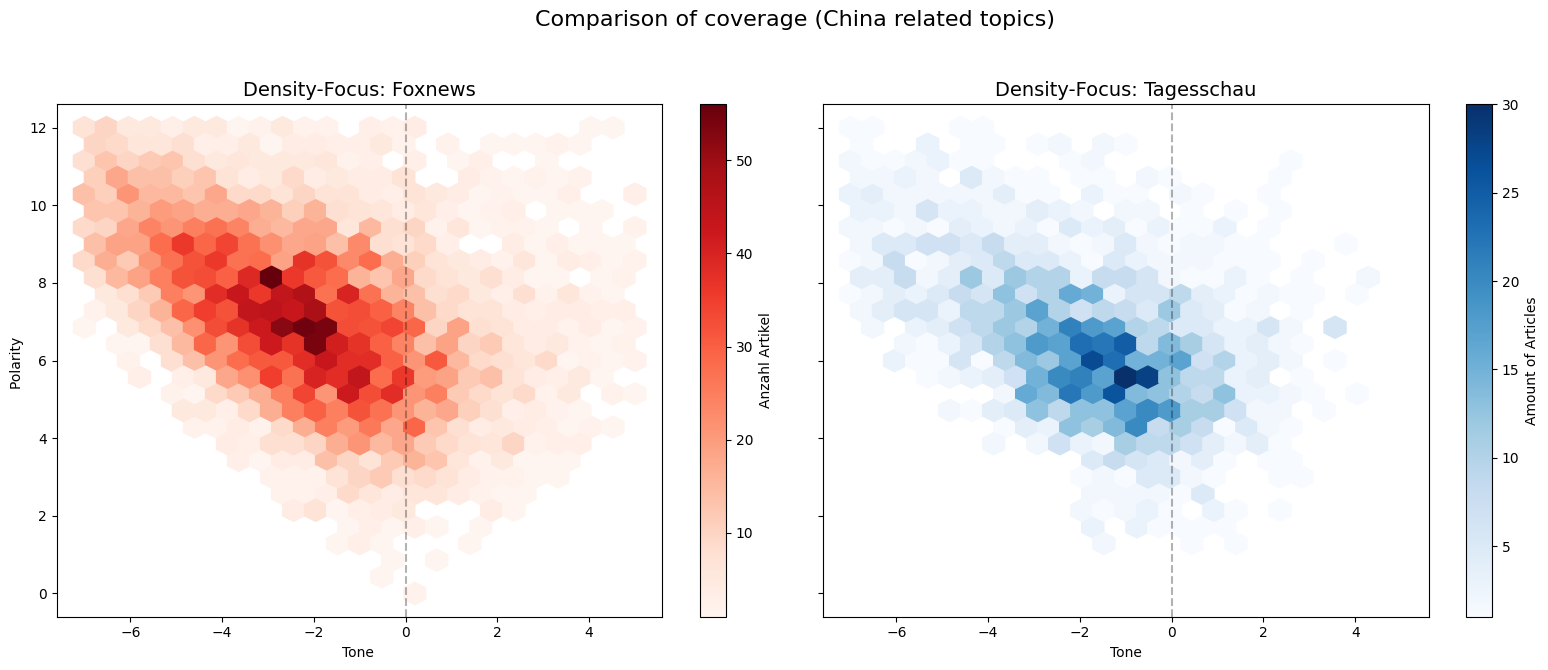

In [3]:
df_bild = df[df['SourceCommonName'].str.contains('foxnews.com', case=False, na=False)]
df_ts = df[df['SourceCommonName'].str.contains('tagesschau', case=False, na=False)]

# 2. Subplots erstellen (1 Zeile, 2 Spalten)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

# Gemeinsamer Bereich für die Achsen (damit der Vergleich fair ist)
# Wir schauen uns das Minimum/Maximum deiner Daten an oder setzen feste Werte:
extent = [-7, 5, 0, 12] 

# Hexbin für Bild (Rot-Farbskala)
hb1 = ax1.hexbin(df_bild['tone'], df_bild['polarity'], gridsize=25, cmap='Reds', mincnt=1, extent=extent)
ax1.set_title('Density-Focus: Foxnews', fontsize=14)
ax1.set_xlabel('Tone ')
ax1.set_ylabel('Polarity ')
fig.colorbar(hb1, ax=ax1, label='Anzahl Artikel')

# Hexbin für Tagesschau (Blau-Farbskala)
hb2 = ax2.hexbin(df_ts['tone'], df_ts['polarity'], gridsize=25, cmap='Blues', mincnt=1, extent=extent)
ax2.set_title('Density-Focus: Tagesschau', fontsize=14)
ax2.set_xlabel('Tone')
fig.colorbar(hb2, ax=ax2, label='Amount of Articles')

# Nulllinie zur Orientierung (neutraler Tone)
for ax in [ax1, ax2]:
    ax.axvline(0, color='black', linestyle='--', alpha=0.3)

plt.suptitle('Comparison of coverage (China related topics)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

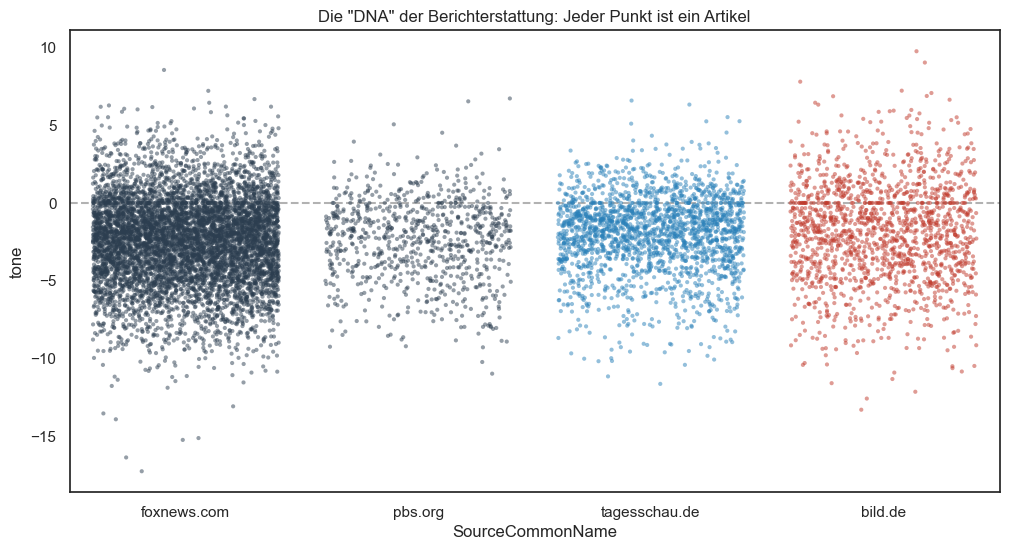

In [ ]:
plt.figure(figsize=(12, 6))

# 'stripplot' mit jitter erzeugt den Beeswarm-Effekt
sns.stripplot(
    data=df_compare, 
    x='SourceCommonName', 
    y='tone', 
    hue='SourceCommonName',
    jitter=0.4, 
    size=3, 
    alpha=0.5, 
    palette=palette
)

plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.title('Die "DNA" der Berichterstattung: Jeder Punkt ist ein Artikel')
plt.show()

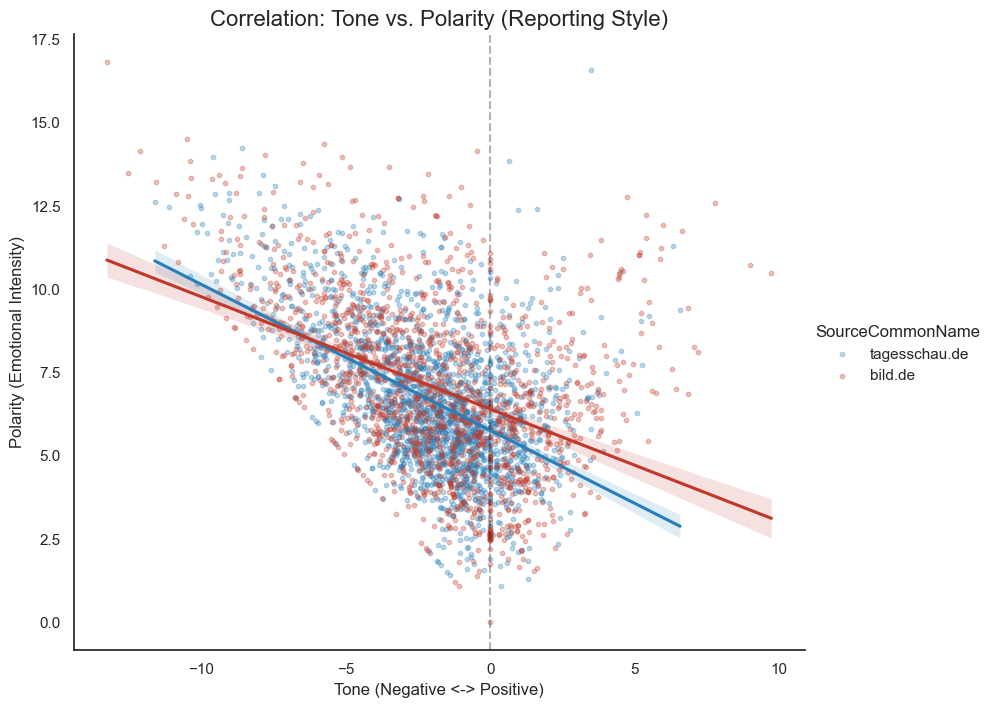

In [ ]:
# 1. Daten filtern (exakte Namen nutzen)
target_sources = ['tagesschau.de', 'bild.de']
df_filtered = df[df['SourceCommonName'].str.lower().isin(target_sources)].copy()

# 2. Visualisierung mit Regressionslinie
# 'lmplot' erstellt separate Linien für jede Quelle
g = sns.lmplot(
    data=df_filtered, 
    x='tone', 
    y='polarity', 
    hue='SourceCommonName', 
    palette={'tagesschau.de': '#2980b9', 'bild.de': '#c0392b'},
    scatter_kws={'alpha': 0.3, 's': 10}, # Punkte klein und transparent
    height=7, 
    aspect=1.2
)

# Optik anpassen
plt.axvline(0, color='black', linestyle='--', alpha=0.3)
plt.title('Correlation: Tone vs. Polarity (Reporting Style)', fontsize=16)
plt.xlabel('Tone (Negative <-> Positive)')
plt.ylabel('Polarity (Emotional Intensity)')

plt.show()

In [8]:
ngos = ['Red Cross', 'Amnesty', 'UNICEF', 'Human Rights Watch']
politicians = ['Scholz', 'Baerbock', 'Habeck', 'Lindner']

def categorize_actor(text):
    if any(x in str(text) for x in politicians): return 'Political Actor'
    if any(x in str(text) for x in ngos): return 'NGO'
    return 'Other'

df['Actor_Group'] = df['V2Persons'].apply(categorize_actor)

25     Other
27     Other
28     Other
57     Other
103    Other
Name: Actor_Group, dtype: str